# ENCS5342 — Assignment #3
## Word Embeddings: Count-Based and Prediction-Based Representations

| | |
|---|---|
| **Course** | ENCS5342 — Information Retrieval with Applications of NLP |
| **Instructor** | Dr. Ahmed I. A. Shawahna — Birzeit University |
| **Semester** | Second Semester 2025–2026 |

<br>
   
| | Name | ID | Section |
|---|---|---|---|
| **Student 1** |Waad ziadeh  | 1220423 | Sec1 |
| **Student 2** | Noor battat | 1210075 | Sec3 |

---

## Grading & Submission

This assignment covers **word embeddings** — dense vector representations that encode semantic
relationships between words. You will implement and compare two major families of approaches:
count-based co-occurrence vectors and prediction-based embeddings (GloVe).

- Work in **groups of two students** (from any section).
- Where a question asks for discussion, add your written explanation in the **Markdown cell immediately below the code cell**.
- You must support your written answers with code. Add additional code cells directly beneath the relevant question to demonstrate your reasoning — for example, by testing different window sizes, exploring word similarities, running analogies, or generating plots. Unsupported written answers will not receive full credit.
- **Run all cells in order** before submitting. Output must be visible beneath each code cell.
- Once you have rerun everything, select File -> Save.
- Submit a **single Jupyter Notebook file** named `A3_ID1_ID2.ipynb` (replace ID1 and ID2 with your student IDs).

---

## Assignment Structure

| Section | Topic | Points |
|---------|-------|--------|
| **Section A** | Count-Based Word Vectors (Co-Occurrence + SVD) | 40 |
| **Section B** | Prediction-Based Word Vectors (GloVe) | 35 |
| **Section C** | Semantic Search with Phrase Embeddings | 15 |
| **Section D** | Bias in Word Embeddings | 10 |
| | **Total** | **100** |

---

## Background Reading

> Jurafsky, D. & Martin, J. H. (2026). *Speech and Language Processing*, 3rd ed., Chapter 5: Embeddings.<br>
> Mikolov, T. et al. (2013). *Efficient Estimation of Word Representations in Vector Space.* ICLR.<br>
> Pennington, J. et al. (2014). *GloVe: Global Vectors for Word Representation.* EMNLP.



---
## Setup — Run This Cell First

This cell installs all required Python packages and sets the global configuration used throughout
the assignment. **Run this cell before any other.**



In [24]:
# All Import Statements Defined Here
import sys
import re
import os
import random
import subprocess

assert sys.version_info[0] == 3
assert sys.version_info[1] >= 8

# Install required packages
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     'gensim', 'scikit-learn', 'matplotlib', 'numpy', 'datasets', 'gdown',
     'nltk', '-q', '--disable-pip-version-check'],
    capture_output=True
)

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pprint
matplotlib.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = [10, 5]

from collections import Counter
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import gensim
import gensim.downloader as api
from gensim.models import KeyedVectors

import nltk
nltk.download('punkt', quiet=True)
from nltk.tokenize import WordPunctTokenizer

START_TOKEN = '<START>'
END_TOKEN   = '<END>'
NUM_SAMPLES = 150

np.random.seed(0)
random.seed(0)

print("Setup complete.")
print(f"  numpy   : {np.__version__}")
print(f"  gensim  : {gensim.__version__}")


Setup complete.
  numpy   : 2.2.1
  gensim  : 4.4.0


---
## Word Vectors

Word vectors are often used as a fundamental component for downstream NLP tasks, e.g., question
answering, text generation, translation, etc., so it is important to build some intuitions as to
their strengths and weaknesses. Here, you will explore two types of word vectors: those derived
from *co-occurrence matrices*, and those derived via *GloVe*.

**Note on Terminology:** The terms "word vectors" and "word embeddings" are often used
interchangeably. The term "embedding" refers to the fact that we are encoding aspects of a
word's meaning in a lower-dimensional space. As
[Wikipedia](https://en.wikipedia.org/wiki/Word_embedding) states, "*conceptually it involves
a mathematical embedding from a space with one dimension per word to a continuous vector space
with a much lower dimension*".



---
# Section A: Count-Based Word Vectors (40 points)

Most word vector models start from the following idea:

*You shall know a word by the company it keeps ([Firth, J. R. 1957:11](https://en.wikipedia.org/wiki/John_Rupert_Firth))*

Many word vector implementations are driven by the idea that similar words, i.e., (near)
synonyms, will be used in similar contexts. As a result, similar words will often be spoken or
written along with a shared subset of words, i.e., contexts. By examining these contexts, we can
try to develop embeddings for our words. With this intuition in mind, many "old school"
approaches to constructing word vectors relied on word counts. Here, we elaborate upon one of
those strategies, *co-occurrence matrices*.

### Co-Occurrence

A co-occurrence matrix counts how often things co-occur in some environment. Given some word
$w_i$ occurring in the document, we consider the *context window* surrounding $w_i$. Supposing
our fixed window size is $n$, then this is the $n$ preceding and $n$ subsequent words in that
document, i.e., words $w_{i-n} \dots w_{i-1}$ and $w_{i+1} \dots w_{i+n}$. We build a
*co-occurrence matrix* $M$, which is a symmetric word-by-word matrix in which $M_{ij}$ is the
number of times $w_j$ appears inside $w_i$'s window among all documents.

**Example: Co-Occurrence with Fixed Window of n=1**:

Document 1: "all that glitters is not gold"

Document 2: "all is well that ends well"


|     *    | `<START>` | all | that | glitters | is   | not  | gold  | well | ends | `<END>` |
|----------|-------|-----|------|----------|------|------|-------|------|------|-----|
| `<START>`    | 0     | 2   | 0    | 0        | 0    | 0    | 0     | 0    | 0    | 0   |
| all      | 2     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| that     | 0     | 1   | 0    | 1        | 0    | 0    | 0     | 1    | 1    | 0   |
| glitters | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| is       | 0     | 1   | 0    | 1        | 0    | 1    | 0     | 1    | 0    | 0   |
| not      | 0     | 0   | 0    | 0        | 1    | 0    | 1     | 0    | 0    | 0   |
| gold     | 0     | 0   | 0    | 0        | 0    | 1    | 0     | 0    | 0    | 1   |
| well     | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 1    | 1   |
| ends     | 0     | 0   | 1    | 0        | 0    | 0    | 0     | 1    | 0    | 0   |
| `<END>`      | 0     | 0   | 0    | 0        | 0    | 0    | 1     | 1    | 0    | 0   |

In NLP, we commonly use `<START>` and `<END>` tokens to mark the beginning and end of sentences,
paragraphs, or documents. These tokens are included in co-occurrence counts, encapsulating each
document, for example: "`<START>` All that glitters is not gold `<END>`".

The matrix rows (or columns) provide word vectors based on word–word co-occurrence, but they
can be very large and sparse. To reduce dimensionality, we employ **Singular Value Decomposition
(SVD)**, selecting the top $k$ principal components. The SVD process decomposes the co-occurrence
matrix $M$ as $M \approx U \Sigma V^\top$; keeping only the top-$k$ singular values yields a
compact matrix $U_k \Sigma_k$ of $k$-dimensional word vectors.

This dimensionality reduction preserves semantic relationships; for instance, *doctor* and
*hospital* will be closer in embedding space than *doctor* and *dog*.

For practical implementation, we use **Truncated SVD** from scikit-learn, which efficiently
computes only the top-$k$ components without forming the full SVD — essential for large
vocabularies.

### Dataset: Large Movie Review (IMDb)

Here, we use the **Large Movie Review Dataset** — a standard benchmark for binary sentiment
classification containing 25,000 highly polar movie reviews for training and 25,000 for testing.
We use a 150-review sample. The `read_corpus` function below loads the reviews, adds `<START>`
and `<END>` tokens, and lowercases all words. You do **not** have to perform any other
pre-processing.



In [25]:
from datasets import load_dataset

imdb_dataset = load_dataset("stanfordnlp/imdb", name="plain_text")

def read_corpus(num_samples=NUM_SAMPLES):
    """Read the first num_samples IMDb training reviews.

    Each review is lowercased, split on whitespace, stripped of non-word
    characters, and wrapped with <START> / <END> tokens.

    Returns:
        list of list of str: one token list per review
    """
    files = imdb_dataset["train"]["text"][:num_samples]
    return [
        [START_TOKEN] +
        [re.sub(r'[^\w]', '', w.lower()) for w in f.split(" ")] +
        [END_TOKEN]
        for f in files
    ]


Let's have a look at what these documents look like….



In [3]:
imdb_corpus = read_corpus()
pprint.pprint(imdb_corpus[:3], compact=True, width=100)
print("Number of documents loaded:", len(imdb_corpus))
print("Tokens in first document  :", len(imdb_corpus[0]))


[['<START>', 'i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because',
  'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first',
  'released', 'in', '1967', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized',
  'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore',
  'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to',
  'see', 'this', 'for', 'myselfbr', 'br', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young',
  'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything',
  'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her',
  'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average',
  'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam',
  'war', 'and', 'race', 'issu

---
### A1 (5 pt) — Implement `distinct_words` [code]

Write a function that returns a **sorted list of unique word types** found across all documents
in the corpus, together with the total count of distinct words.

You can use `for` loops, but try using Python list comprehensions (which are generally faster).
[This tip](https://coderwall.com/p/rcmaea/flatten-a-list-of-lists-in-one-line-in-python) may be
useful for flattening a list of lists. You may also find
[Python sets](https://www.w3schools.com/python/python_sets.asp) useful for deduplication.



In [29]:
def distinct_words(corpus):
    """Determine all distinct word types in the corpus.

    Params:
        corpus (list of list of str): corpus of tokenized documents

    Returns:
        corpus_words (list of str): sorted list of distinct words across the corpus
        n_corpus_words (int): number of distinct words across the corpus
    """
    corpus_words = []
    n_corpus_words = -1

    # ------------------
    # Write your implementation here.
    all_words = [word for doc in corpus for word in doc]

    corpus_words = sorted(list(set(all_words)))

    n_corpus_words = len(corpus_words)

    # ------------------

    return corpus_words, n_corpus_words


In [30]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# ---------------------

test_corpus = [
    "{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "),
    "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")
]
test_corpus_words, num_corpus_words = distinct_words(test_corpus)

ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold",
                                 "All's", "glitters", "isn't", "well", END_TOKEN])
ans_num_corpus_words = len(ans_test_corpus_words)

assert num_corpus_words == ans_num_corpus_words,     "Incorrect number of distinct words. Correct: {}. Yours: {}".format(
        ans_num_corpus_words, num_corpus_words)
assert test_corpus_words == ans_test_corpus_words,     "Incorrect corpus_words.\nCorrect: {}\nYours:   {}".format(
        str(ans_test_corpus_words), str(test_corpus_words))

print("-" * 80)
print("Passed All Tests!")
print("-" * 80)


--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


---
### A2 (10 pt) — Implement `compute_co_occurrence_matrix` [code]

Write a function that constructs a co-occurrence matrix for a given window size $n$ (default 4),
counting words $n$ positions before and $n$ positions after each target word, within each
document. The matrix must be symmetric, and its rows/columns must follow the ordering produced
by `distinct_words`.

If you are not familiar with NumPy, refer to the
[Python NumPy tutorial](http://cs231n.github.io/python-numpy-tutorial/).



In [31]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """Compute the symmetric word co-occurrence matrix.

    For each word w_i in a document, every word within `window_size` positions
    to its left and right (not crossing document boundaries) co-occurs with w_i.

    Params:
        corpus (list of list of str): tokenized documents
        window_size (int): number of context positions on each side

    Returns:
        M (np.ndarray shape (V, V)): co-occurrence counts
        word2ind (dict): maps each word to its row/column index in M
    """

    words, n_words = distinct_words(corpus)

    # Create empty matrix
    M = np.zeros((n_words, n_words))

    # Create word -> index dictionary
    word2ind = {}

    for i, word in enumerate(words):
        word2ind[word] = i

    # Loop through each document
    for doc in corpus:

        # Loop through each word in document
        for i, word in enumerate(doc):

            # Get current word index
            word_idx = word2ind[word]

            # Define context window boundaries
            start = max(0, i - window_size)
            end = min(len(doc), i + window_size + 1)

            # Loop through surrounding words
            for j in range(start, end):

                # Skip the target word itself
                if i == j:
                    continue

                context_word = doc[j]
                context_idx = word2ind[context_word]

                # Increase co-occurrence count
                M[word_idx][context_idx] += 1

    return M, word2ind

In [32]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# ---------------------

test_corpus = [
    "{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "),
    "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")
]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)

M_test_ans = np.array(
    [[0., 0., 0., 0., 0., 0., 1., 0., 0., 1.],
     [0., 0., 1., 1., 0., 0., 0., 0., 0., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 1., 0.],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 1.],
     [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
     [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.],
     [1., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
     [0., 0., 0., 0., 0., 1., 1., 0., 0., 0.],
     [0., 0., 1., 0., 1., 1., 0., 0., 0., 1.],
     [1., 0., 0., 1., 1., 0., 0., 0., 1., 0.]]
)
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold",
                                 "All's", "glitters", "isn't", "well", END_TOKEN])
word2ind_ans = dict(zip(ans_test_corpus_words, range(len(ans_test_corpus_words))))

assert word2ind_ans == word2ind_test,     "Your word2ind is incorrect:\nCorrect: {}\nYours: {}".format(word2ind_ans, word2ind_test)
assert M_test.shape == M_test_ans.shape,     "M matrix has incorrect shape.\nCorrect: {}\nYours: {}".format(M_test.shape, M_test_ans.shape)
for w1 in word2ind_ans:
    for w2 in word2ind_ans:
        i, j = word2ind_ans[w1], word2ind_ans[w2]
        if M_test[i, j] != M_test_ans[i, j]:
            print("Correct M:"); print(M_test_ans)
            print("Your M:");    print(M_test)
            raise AssertionError(
                "Incorrect count at ({},{})=({},{}): yours={}, expected={}.".format(
                    i, j, w1, w2, M_test[i, j], M_test_ans[i, j]))

print("-" * 80)
print("Passed All Tests!")
print("-" * 80)


--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


---
### A3 (7 pt) — Implement `reduce_to_k_dim` [code]

Write a function that reduces the co-occurrence matrix from $(V \times V)$ to $(V \times k)$
using **Truncated SVD**.

In terms of the full SVD $M = U \Sigma V^\top$, Truncated SVD returns the top-$k$ approximation
$U_k \Sigma_k$. This is the value your function should return.

**Note:** Use
[`sklearn.decomposition.TruncatedSVD`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)
with `n_iter=10` and `random_state=0`. Do **not** use `numpy.linalg.svd` (it computes the full
SVD and will run out of memory on large matrices).



In [33]:
def reduce_to_k_dim(M, k=2):
    """Reduce a co-occurrence matrix from (V, V) to (V, k) using Truncated SVD.

    The returned matrix is U_k * Sigma_k — the first k left singular vectors
    scaled by their singular values.

    Params:
        M (np.ndarray, shape (V, V)): co-occurrence count matrix
        k (int): target embedding dimension (default 2)

    Returns:
        M_reduced (np.ndarray, shape (V, k)): k-dimensional word embeddings
    """
    n_iters = 10     # pass this as n_iter to TruncatedSVD
    M_reduced = None
    print("Running Truncated SVD over %i words..." % M.shape[0])

    # ------------------
    # Write your implementation here.

    svd = TruncatedSVD(n_components=k, n_iter=n_iters, random_state=0)

    M_reduced = svd.fit_transform(M)
    # ------------------

    print("Done.")
    return M_reduced


In [34]:
# ---------------------
# Run this sanity check
# Only checks output dimensions.
# ---------------------

test_corpus = [
    "{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "),
    "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")
]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)
M_test_reduced = reduce_to_k_dim(M_test, k=2)

assert M_test_reduced.shape[0] == 10,     "M_reduced has {} rows; should have 10".format(M_test_reduced.shape[0])
assert M_test_reduced.shape[1] == 2,     "M_reduced has {} columns; should have 2".format(M_test_reduced.shape[1])

print("-" * 80)
print("Passed All Tests!")
print("-" * 80)


Running Truncated SVD over 10 words...
Done.
--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


---
### A4 (5 pt) — Implement `plot_embeddings` [code]

Write a function that produces a labelled 2D scatter plot of word embeddings using Matplotlib.
Plot **only** the words listed in the `words` parameter — not the entire vocabulary.
Each plotted point must be annotated with the word it represents.

For inspiration, see the
[Matplotlib gallery](https://matplotlib.org/gallery/index.html) or adapt
[this example](http://web.archive.org/web/20190924160434/https://www.pythonmembers.club/2018/05/08/matplotlib-scatter-plot-annotate-set-text-at-label-each-point/).



In [ ]:
def plot_embeddings(M_reduced, word2ind, words, title="Word Embeddings (2D)"):
    """Plot a labelled 2D scatter of selected word embeddings.

    Only the words listed in `words` are plotted; all other vocabulary words
    in M_reduced are ignored.

    Params:
        M_reduced (np.ndarray, shape (V, 2)): 2D embedding matrix
        word2ind  (dict): maps each word to its row index in M_reduced
        words     (list of str): words to plot and label
        title     (str): plot title
    """

    # ------------------
    # Write your implementation here.
    plt.figure(figsize=(8,8))

    for word in words:

        idx = word2ind[word]

        x = M_reduced[idx, 0]
        y = M_reduced[idx, 1]

        plt.scatter(x, y)

        plt.annotate(word, (x, y))

    plt.title(title)

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")

   
    plt.show()
  # ------------------

--------------------------------------------------------------------------------
Sanity-check plot:


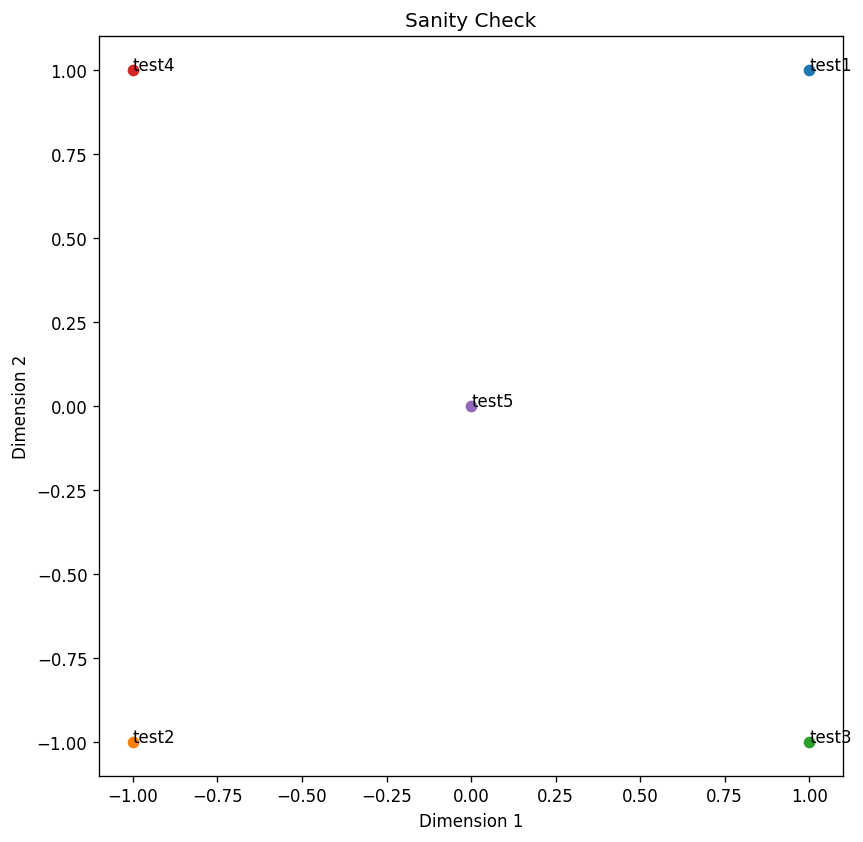

--------------------------------------------------------------------------------


In [36]:
# ---------------------
# Run this sanity check
# The plot should show five labelled points at the given coordinates.
# ---------------------

print("-" * 80)
print("Sanity-check plot:")

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]], dtype=float)
word2ind_plot_test = {'test1': 0, 'test2': 1, 'test3': 2, 'test4': 3, 'test5': 4}
words_test = ['test1', 'test2', 'test3', 'test4', 'test5']
plot_embeddings(M_reduced_plot_test, word2ind_plot_test, words_test, title="Sanity Check")

print("-" * 80)


---
### A5 (13 pt) — Co-Occurrence Plot Analysis [code + written]

Now, we bring together all the functions you have implemented. We will compute the co-occurrence
matrix with a fixed window of 4 (the default), over the full 150-review IMDb corpus, then use
Truncated SVD to obtain 2-dimensional embeddings. We then **row-normalise** the embeddings so
that each word vector has unit length and angular distance is meaningful:

```python
M_lengths    = np.linalg.norm(M_reduced, axis=1)
M_normalized = M_reduced / M_lengths[:, np.newaxis]   # NumPy broadcasting
```

Run the cell below to produce the plot (it may take up to a minute).



Running Truncated SVD over 5880 words...
Done.


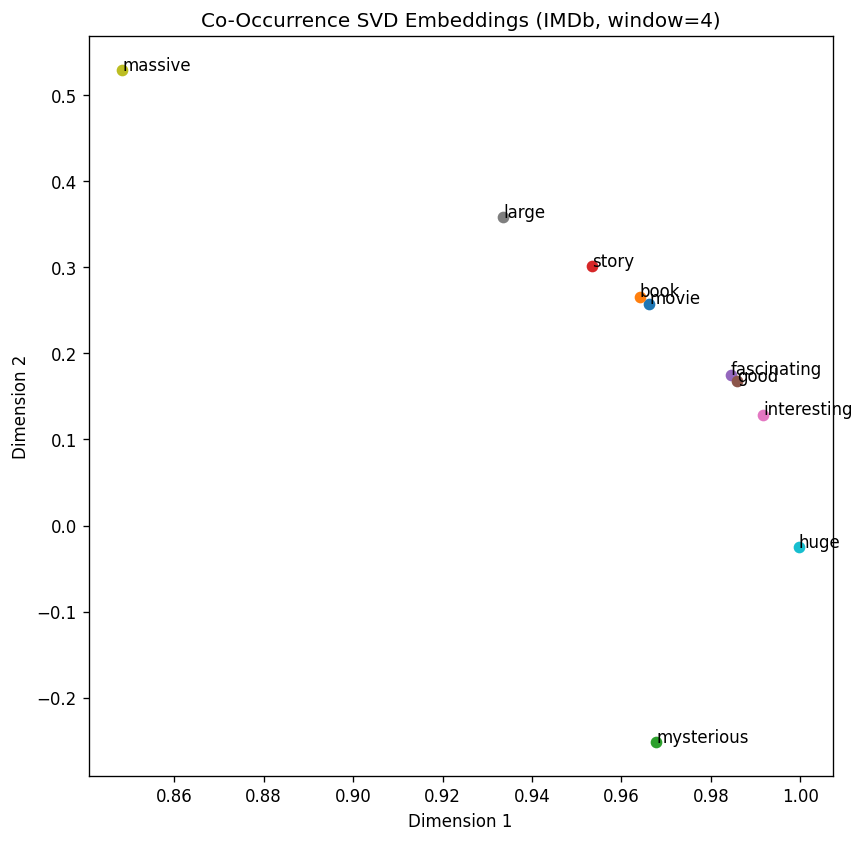

In [37]:
# -----------------------------
# Run This Cell to Produce Your Plot
# ------------------------------
imdb_corpus = read_corpus()
M_co_occurrence, word2ind_co_occurrence = compute_co_occurrence_matrix(imdb_corpus)
M_reduced_co_occurrence = reduce_to_k_dim(M_co_occurrence, k=2)

# Row-normalise so every vector lies on the unit circle
M_lengths    = np.linalg.norm(M_reduced_co_occurrence, axis=1)
M_normalized = M_reduced_co_occurrence / M_lengths[:, np.newaxis]   # broadcasting

words_a5 = ['movie', 'book', 'mysterious', 'story', 'fascinating',
            'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_normalized, word2ind_co_occurrence, words_a5,
                title="Co-Occurrence SVD Embeddings (IMDb, window=4)")


**Verify that your figure matches "!uestion_A.5.png" in the assignment zip. If not, use the figure in "Question_A.5.png" to answer the next two questions.**<br><br>

**A5a (4 pt)** — Find at least **two groups** of words that cluster together in the 2D plot.
For each cluster, identify the words involved and explain *why* those words appear close together.

**Answer:** 

1. movie, book, story
These words are related because they all talk about content and storytelling. In movie reviews, these words usually appear in similar contexts, so the model placed them close together.


2. good, fascinating, interesting
These words are all positive descriptive words. They are often used in reviews to describe movies in a similar way, so their embeddings became close.
---

**A5b (3 pt)** — Identify at least **two pairs** of words that you would expect to cluster together but do not. Explain why the co-occurrence method may have failed to capture their similarity.

**Answer:** 

1. huge and massive 
These words have almost the same meaning, but they are not very close in the plot. This may be because the dataset is small, so the model did not see enough similar contexts for both words.

2. large and massive 
These words are also similar in meaning, but they are separated in the embedding space. Co-occurrence methods depend on nearby words, and these words may have appeared in different contexts in the reviews.
---

**A5c (3 pt)** — For a corpus with 50,000 unique words, how many entries does raw co-occurrence matrix have? Explain why storing and computing with this matrix becomes problematic at scale, and
describe how Truncated SVD addresses both problems.

**Answer:** 

For 50,000 unique words, the co-occurrence matrix would have:

                   50000 × 50000 = 2.5×10^9  entries

This is a very large matrix, so it needs a lot of memory and computations become slow. Also, most values in the matrix are zeros, which makes it inefficient.

Truncated SVD helps by reducing the matrix into a smaller representation while keeping the most important information. This makes storage and computation much easier and faster.


---

**A5d (3 pt)** — Window size $n$ is an important hyperparameter. Predict how the clusters
in the plot would change if you re-ran the experiment with (a) $n=1$ and (b) $n=10$.
Explain your reasoning for each case in terms of what co-occurrence information each window
size captures.

**Answer:** 

(a) If n=1

The model would only look at very close neighboring words. The embeddings would focus more on local relationships, so some semantic similarities may become weaker.

(b) If n=10

The model would look at a larger context around each word. This can help capture broader meanings and more semantic relationships, but it may also add noise because unrelated words farther away are included.

---


---
# Section B: Prediction-Based Word Vectors (35 points)

More recently, prediction-based word vectors have demonstrated better performance than
count-based methods. Here, we explore **GloVe (Global Vectors for Word Representation)**,
which combines the benefits of count-based and prediction-based approaches: it builds a
*global co-occurrence matrix* across the entire corpus and then factorizes it using a
weighted least-squares objective — capturing both local context patterns and global
corpus statistics.

Please revisit the lecture slides for more details on the Word2Vec and GloVe algorithms.
You can also challenge yourself by reading
[GloVe's original paper](https://nlp.stanford.edu/pubs/glove.pdf).

We use the pre-trained model **`glove-wiki-gigaword-200`**:
- **Training data:** Wikipedia 2014 + Gigaword 5 English newswire
- **Corpus size:** 6 billion tokens
- **Vocabulary:** 400,000 words
- **Embedding dimension:** 200

**Note:** The first time you run the loading cell, the model will be downloaded (~900 MB) and
this may take several minutes. Subsequent runs will load from cache and take 1–2 minutes.



In [38]:
def load_embedding_model():
    """Load pre-trained GloVe vectors (glove-wiki-gigaword-200).

    Returns:
        wv_from_bin (KeyedVectors): 400,000 embeddings, each of length 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

wv_from_bin = load_embedding_model()


Loaded vocab size 400000


#### Note: If you receive a "Connection reset by peer" error, simply rerun the cell to resume the download.



### Reducing Dimensionality of GloVe Embeddings

To compare GloVe embeddings with the co-occurrence embeddings from Section A, we reduce the
200-dimensional GloVe vectors to 2D using the `reduce_to_k_dim` function you implemented.
To avoid memory issues, we work with a sample of 40,000 GloVe vectors.

Run the following cells to:
1. Build a matrix $M$ containing 40,000 GloVe vectors (plus any required words not in the random sample)
2. Reduce $M$ from 200-dimensional to 2-dimensional using Truncated SVD



In [39]:
def get_matrix_of_vectors(wv_from_bin, required_words):
    """Sample 40,000 GloVe vectors into a matrix M, ensuring required_words are included.

    Params:
        wv_from_bin (KeyedVectors): the loaded GloVe model
        required_words (list of str): words that must be present in M regardless of sampling

    Returns:
        M (np.ndarray, shape (num_words, 200)): matrix of GloVe vectors
        word2ind (dict): maps each word to its row index in M
    """
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in word2ind:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind


In [40]:
# -----------------------------------------------------------------
# Run this cell to reduce 200-dimensional GloVe vectors to 2 dimensions.
# This should run quickly (under a minute).
# -----------------------------------------------------------------
words_b1 = ['movie', 'book', 'mysterious', 'story', 'fascinating',
            'good', 'interesting', 'large', 'massive', 'huge']

M_glove, word2ind_glove = get_matrix_of_vectors(wv_from_bin, words_b1)
M_glove_reduced = reduce_to_k_dim(M_glove, k=2)

# Row-normalise so every vector lies on the unit circle
M_glove_lengths     = np.linalg.norm(M_glove_reduced, axis=1)
M_glove_normalized  = M_glove_reduced / M_glove_lengths[:, np.newaxis]   # broadcasting


Shuffling words ...
Putting 400000 words into word2ind and matrix M...
Done.
Running Truncated SVD over 400000 words...
Done.


---
### B1 (8 pt) — GloVe Plot Analysis [code + written]

Run the cell below to plot the 2D GloVe embeddings for the same ten words used in A5.



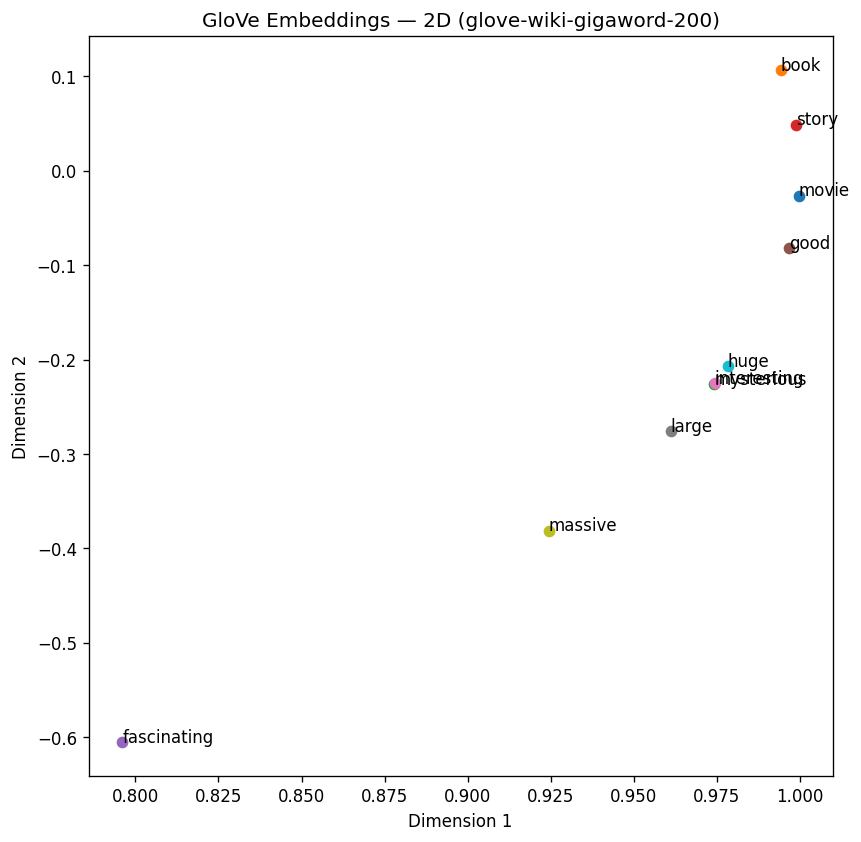

In [41]:
plot_embeddings(M_glove_normalized, word2ind_glove, words_b1,
                title="GloVe Embeddings — 2D (glove-wiki-gigaword-200)")


**Verify that your figure matches "Question_B.1.png" in the assignment zip. If not, use the figure in "Question_B.1.png" (and the figure in "Question_A.5.png", if applicable) to answer the next two questions.**<br><br>

---

**B1a (3 pt)** — Describe **one clear difference** and **one clear similarity** between this
GloVe plot and the co-occurrence SVD plot from A5.

**Answer:** 

One clear similarity is that both plots grouped related words together. For example, movie, book, and story are close in both plots because they are related to storytelling and media.

One clear difference is that the GloVe plot shows cleaner and more organized clusters. The words in the GloVe embeddings are generally closer in a more meaningful way because GloVe was trained on a much larger dataset.

---

**B1b (3 pt)** — Why might the GloVe plot (Question_B.1.png) differ from the plot generated earlier from the co-occurrence matrix (Question_A.5.png)?

**Answer:** 

The GloVe plot is different because GloVe was trained on billions of words from large datasets like Wikipedia and news articles, while the co-occurrence matrix in Section A used only 150 IMDb reviews.
Because of the larger training data, GloVe learns stronger semantic relationships between words and captures meanings more accurately. The co-occurrence model depends only on local word counts in a very small corpus, so its embeddings are noisier and less reliable.

---

**B1c (2 pt)** — Our co-occurrence matrix was built on 150 IMDb movie reviews, while GloVe was
trained on 6 billion tokens. Give **two concrete examples** of word relationships that GloVe
captures correctly but that the 150-review co-occurrence model likely cannot, and explain why
corpus size is responsible for the difference.

**Answer:** 

One example is huge and massive.
GloVe captures that these words are very similar because it has seen them used in many similar contexts across billions of words. The small IMDb corpus may not contain enough examples of both words appearing in similar situations.

Another example is good and interesting.
GloVe places them close because both are commonly used as positive descriptive words. The co-occurrence model built from only 150 reviews may not have enough data to learn this relationship clearly.

The larger corpus helps GloVe learn more accurate word relationships because it sees words in many different contexts and much more frequently.




---
### B2 (5 pt) — Words with Multiple Meanings (Polysemy) [code + written]

Polysemes and homonyms are words that have more than one meaning (see this
[Wikipedia page](https://en.wikipedia.org/wiki/Polysemy) for the distinction between them).
Find a word with **at least two different meanings** such that the top-10 most similar words
(by cosine similarity) contain words associated with **both** meanings.

For example, "leaves" captures both the "to depart" and "plant structure" senses in its top
neighbours, and "scoop" captures both "ice cream serving utensil" and "exclusive news story".
You will probably need to try several words before you find one that works.

Use `wv_from_bin.most_similar(word)` to retrieve the top-10 neighbours. See the
[Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.most_similar)
for details.



In [42]:
# ------------------
# Write your implementation here.

word = "mouse"

similar_words = wv_from_bin.most_similar(word, topn=10)

print("Top similar words for:", word)

for w, score in similar_words:
    print(w, ":", score)

# ------------------

Top similar words for: mouse
mice : 0.6580958962440491
keyboard : 0.5548278093338013
rat : 0.5433949828147888
rabbit : 0.5192376971244812
cat : 0.5077415704727173
cursor : 0.5058691501617432
trackball : 0.5048902630805969
joystick : 0.49841049313545227
mickey : 0.47242844104766846
clicks : 0.4722806215286255


**Answer:** State the word you chose, identify the two meanings visible in the top-10 list,
and explain why many polysemous words you tried showed only one meaning.

I chose the word mouse because it has multiple meanings.
one meaning is the animal, shown by similar words such as rat, rabbit, cat, and mickey.
The second meaning is the computer device, shown by words like keyboard, cursor, trackball, and clicks.

Many polysemous words showed only one meaning because GloVe produces a single vector per word type, averaging across all its senses. When one meaning is far more frequent in the training corpus.




---
### B3 (5 pt) — Synonyms & Antonyms [code + written]

Cosine distance is defined as $1 - \text{cosine similarity}$.

Find **one** word triple $(w_1, w_2, w_3)$ where:
- $w_1$ and $w_2$ are **synonyms** (similar meaning), and
- $w_1$ and $w_3$ are **antonyms** (opposite meaning), yet
- $\text{cosine distance}(w_1, w_3) < \text{cosine distance}(w_1, w_2)$

In other words, find a case where the antonym is *geometrically closer* to $w_1$ than
the synonym is. The worked example $w_1$="happy", $w_2$="cheerful", $w_3$="sad" is **not**
an acceptable answer — find a different triple.

Use `wv_from_bin.distance(w1, w2)` for cosine distance. See the
[Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.distance).



In [43]:
# ------------------
# Write your implementation here.
w1 = "hot"
w2 = "warm"      # synonym
w3 = "cold"      # antonym

d_syn = wv_from_bin.distance(w1, w2)
d_ant = wv_from_bin.distance(w1, w3)

print("Distance between", w1, "and", w2, "=", d_syn)
print("Distance between", w1, "and", w3, "=", d_ant)

# ------------------

Distance between hot and warm = 0.41116726
Distance between hot and cold = 0.40621883


**Answer:** State your triple $(w_1, w_2, w_3)$, confirm the distances, and explain *why*
the antonym ends up closer in vector space than the synonym.

I chose the triplet (hot, warm, cold)
hot and warm are synonyms, while hot and cold are antonyms
The cosine distance between hot and cold is 0.406, while the distance between hot and warm is 0.411
This means the antonym is geometrically closer than the synonym in the embedding space.
This happens because antonyms often appear in very similar contexts. For example, both hot and cold are commonly used when talking about weather, temperature, food, and drinks, so the model learns similar contextual patterns for them.


---
### B4 (5 pt) — Analogies with Word Vectors [code + written]

Word vectors have been shown to *sometimes* exhibit the ability to solve analogies.

As an example, for the analogy "man : grandfather :: woman : x" (read: man is to grandfather as woman is to x), what is x?

In the cell below, we show you how to use word vectors to find x using the `most_similar` function from the __[GenSim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar)__. The function finds words that are most similar to the words in the `positive` list and most dissimilar from the words in the `negative` list (while omitting the input words, which are often the most similar; see [this paper](https://www.aclweb.org/anthology/N18-2039.pdf)). The answer to the analogy will have the highest cosine similarity (largest returned numerical value).



In [44]:
# Run this cell to answer the analogy:  man : grandfather :: woman : x
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))


[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200808525085449),
 ('daughter', 0.7168302536010742),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005682587623596),
 ('father', 0.6659888029098511),
 ('aunt', 0.6623409390449524),
 ('grandson', 0.6618767976760864),
 ('grandparents', 0.644661009311676),
 ('wife', 0.6445354223251343)]


Let $m$, $g$, $w$, and $x$ denote the word vectors for `man`, `grandfather`, `woman`, and the answer, respectively. Using **only** vectors $m$, $g$, $w$, and the vector arithmetic operators $+$ and $-$ in your answer, what is the expression in which we are maximizing cosine similarity with $x$?

**Hint:** Recall that word vectors are simply multi-dimensional vectors that represent a word. It might help to draw out a 2D example using arbitrary locations of each vector. Where would `man` and `woman` lie in the coordinate plane relative to `grandfather` and the answer?

**Answer:** 

The model correctly predicted grandmother as the answer to the analogy: man : grandfather :: woman : x

This works because word embeddings capture semantic relationships between words. 
The vector operation: x≈grandfather−man+woman
produces a vector close to grandmother. This shows that similar relationships between words can be represented geometrically in the embedding space


---
### B5 (6 pt) — Finding and Evaluating Analogies [code + written]

**B5a (2 pt)** — It is clear that "grandmother" completes the analogy "man : grandfather ::
woman : ?". Yet `most_similar` returns words like "granddaughter", "daughter", or "mother"
in high positions. Give an intuitive explanation for why these near-correct words appear.

**Answer:** 

Words like mother, daughter, and granddaughter appear because they are semantically related to family relationships and femininity.
Their vectors are close to grandmother in the embedding space, so the model considers them near-correct answer

---

**B5b (2 pt)** — Find an analogy that **holds** according to the GloVe vectors, i.e., the
intended answer is the top-ranked word. State the analogy in the form **x : y :: a : b**
and run the code below to verify. If the analogy is non-obvious, explain in one sentence why
it works.

**Note:** You may need to try many analogies before finding one that works.



In [45]:
# B5b — Define your analogy variables and verify
# Replace the empty strings with your chosen words.
x, y, a, b = "king", "man", "queen", "woman"
# ------------------
# Write your implementation here.

result = wv_from_bin.most_similar(
    positive=[x, b],
    negative=[y]
)

for word, score in result:
    print(word, ":", score)


# ------------------

queen : 0.6978678107261658
princess : 0.6081745028495789
monarch : 0.5889754891395569
throne : 0.5775108933448792
prince : 0.5750998258590698
elizabeth : 0.5463595986366272
daughter : 0.5399126410484314
kingdom : 0.5318052768707275
mother : 0.5168544054031372
crown : 0.5164473056793213


**Answer:** 

Analogy: king : man :: queen : woman

The model correctly predicted queen as the top result.

This works because the relationship between king and man is similar to the relationship between queen and woman.

The word embeddings capture gender relationships and represent them geometrically in the vector space.




---

**B5c (2 pt)** — The cell below tests the analogy "hand : glove :: foot : **sock**", but the
model returns an unexpected result. Run the cell and explain *why* the expected answer "sock"
does not appear at the top.

In [46]:
# B5c — Run this cell and observe the result
pprint.pprint(wv_from_bin.most_similar(positive=['foot', 'glove'], negative=['hand']))


[('45,000-square', 0.4922032654285431),
 ('15,000-square', 0.4649604558944702),
 ('10,000-square', 0.4544755816459656),
 ('6,000-square', 0.44975775480270386),
 ('3,500-square', 0.444133460521698),
 ('700-square', 0.44257497787475586),
 ('50,000-square', 0.4356396794319153),
 ('3,000-square', 0.43486514687538147),
 ('30,000-square', 0.4330596923828125),
 ('footed', 0.43236875534057617)]


**Answer:** 

The analogy fails because "glove" and "sock" don't appear together in similar text contexts. While both are clothing items, they appear in very different contexts 

Word embeddings learn from text co-occurrence patterns, not real-world logic. The model doesn't understand that gloves go on hands and socks go on feet. Since the vector calculation glove + foot - hand doesn't point clearly toward "sock," the model returns random nearby words like "45,000-square" instead.



---
### B6 (6 pt) — Visualizing GloVe Vectors: PCA vs t-SNE [code + written]

GloVe vectors live in 200-dimensional space — impossible to visualize directly. We use two
standard dimensionality reduction methods to project them into 2D:

| Method | Type | Preserves | Speed |
|--------|------|-----------|-------|
| **PCA** | Linear | Global variance structure | Fast |
| **t-SNE** | Non-linear | Local neighbourhood clusters | Slow (1–3 min) |

We visualize the **top 1,000 most frequent words** in the GloVe vocabulary using
**Bokeh** — an interactive visualization library that lets you hover over each dot to
see the word it represents, scroll to zoom, and drag to pan.

We work with the most frequent words because they appear most often during training and
therefore have the most reliable vector representations.

Run all five cells below, interact with the plots, then answer the discussion questions.



In [47]:
# B6 Step 1 — Install Bokeh and select the 1,000 most frequent GloVe words.
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'bokeh', '-q',
                '--disable-pip-version-check'], capture_output=True)

import bokeh.models as bm
import bokeh.plotting as pl
from bokeh.io import output_notebook
output_notebook()   # render Bokeh plots inline in the notebook

words_top1k = sorted(
    wv_from_bin.key_to_index.keys(),
    key=lambda w: wv_from_bin.get_vecattr(w, 'count'),
    reverse=True
)[:1000]

word_vectors_1k = np.array([wv_from_bin.get_vector(w) for w in words_top1k])

print(f"Words selected : {len(words_top1k)}")
print(f"Matrix shape   : {word_vectors_1k.shape}   (1000 words × 200 dims)")
print(f"Top 20 words   : {words_top1k[:20]}")


Loading BokehJS ...

Words selected : 1000
Matrix shape   : (1000, 200)   (1000 words × 200 dims)
Top 20 words   : ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that', 'on', 'is', 'was', 'said', 'with', 'he', 'as']


In [48]:
# B6 Step 2 — Define the interactive Bokeh plotting function.
# Copied directly from the ENCS5342 Embedding Lab.

def draw_vectors(x, y, radius=10, alpha=0.25, color='blue',
                 width=900, height=600, show=True, **kwargs):
    """
    Draw an interactive 2D scatter plot of word vectors using Bokeh.

    Parameters:
        x, y         : 1D arrays of x and y coordinates
        radius       : dot size
        alpha        : dot transparency (0 = invisible, 1 = solid)
        color        : dot color (string or list of strings)
        width, height: plot dimensions in pixels
        **kwargs     : extra columns shown in the hover tooltip (e.g., token=words)

    Interaction:
        - Hover over a dot to see its word label
        - Scroll to zoom in/out
        - Click and drag to pan
    """
    if isinstance(color, str):
        color = [color] * len(x)

    data_source = bm.ColumnDataSource({'x': x, 'y': y, 'color': color, **kwargs})

    fig = pl.figure(active_scroll='wheel_zoom', width=width, height=height,
                    title="Word Vector Visualization")
    fig.scatter('x', 'y', size=radius, color='color', alpha=alpha, source=data_source)
    fig.add_tools(bm.HoverTool(tooltips=[(key, '@' + key) for key in kwargs.keys()]))

    if show:
        pl.show(fig)
    return fig

print("draw_vectors() function defined.")


draw_vectors() function defined.


In [49]:
# B6 Step 3 — PCA: reduce 200D → 2D, standardize, then plot interactively.
pca = PCA(n_components=2, random_state=0)
word_vectors_pca = pca.fit_transform(word_vectors_1k)
word_vectors_pca = StandardScaler().fit_transform(word_vectors_pca)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.1%}")
print(f"Output shape: {word_vectors_pca.shape}")
print()
print("Hover over any dot to see which word it represents.")

draw_vectors(
    word_vectors_pca[:, 0],
    word_vectors_pca[:, 1],
    token=words_top1k,
    color='steelblue'
)


Explained variance: PC1=5.6%, PC2=4.7%
Total variance captured: 10.3%
Output shape: (1000, 2)

Hover over any dot to see which word it represents.


figure(id='p1011', ...)

In [50]:
# B6 Step 4 — t-SNE: reduce 200D → 2D (takes 1–3 minutes), then plot interactively.
print("Running t-SNE on 1,000 word vectors (200D → 2D) ...")
print("This may take 1–3 minutes.\n")

tsne = TSNE(n_components=2, random_state=0, verbose=0)
word_vectors_tsne = tsne.fit_transform(word_vectors_1k)
word_vectors_tsne = StandardScaler().fit_transform(word_vectors_tsne)

print(f"t-SNE complete. Output shape: {word_vectors_tsne.shape}")
print()
print("Hover over any dot to see which word it represents.")

draw_vectors(
    word_vectors_tsne[:, 0],
    word_vectors_tsne[:, 1],
    token=words_top1k,
    color='seagreen'
)


Running t-SNE on 1,000 word vectors (200D → 2D) ...
This may take 1–3 minutes.

t-SNE complete. Output shape: (1000, 2)

Hover over any dot to see which word it represents.


figure(id='p1062', ...)

**B6a (2 pt)** — Identify **two distinct clusters** in the t-SNE plot. For each cluster,
name at least three words in it and state what semantic or grammatical category they share.

**Answer:**

Cluster 1:  "order," "special," "position"

Cluster 2: "against," "while," "close"

---

**B6b (2 pt)** — Compare the PCA and t-SNE plots. Why does t-SNE reveal tighter and more
distinct clusters? In your answer, describe what quantity each method optimises during
dimensionality reduction.

**Answer:** 

The t-SNE plot shows tighter and more distinct clusters because t-SNE focuses on preserving local neighbourhood relationships between nearby points.

In contrast, PCA preserves the overall global variance structure of the data using a linear transformation.
As a result, t-SNE separates similar words into clearer groups, while PCA produces a more spread-out visualization.

---

**B6c (2 pt)** — We selected the top 1,000 **most frequent** words rather than 1,000 randomly
chosen words. Explain why frequent words are a better choice for this visualization, and what
risk arises if rare words are included instead.

**Answer:** 

Frequent words are a better choice because they appear many times during training, so their embeddings are more reliable and meaningful.

Rare words may not have enough context examples, which can produce noisy or inaccurate vectors.
Including many rare words could make the visualization less clear and reduce the quality of the clusters.



---
# Section C: Semantic Search with Phrase Embeddings (15 points)

Individual word vectors are powerful, but real queries and documents are phrases or sentences.
A simple and effective way to represent a phrase as a single vector is to **average** the
GloVe vectors of its constituent words:

$$\vec{\text{phrase}} = \frac{1}{|W_{\text{found}}|} \sum_{w \in W_{\text{found}}} \vec{w}$$

where $W_{\text{found}}$ is the set of words in the phrase that exist in the GloVe vocabulary.
Words not in the vocabulary are skipped; if no words are found, a zero vector is returned.

Once we can embed phrases, we build a simple **semantic search engine**: embed a query,
then rank all documents by cosine similarity to the query vector.

---
## C0 (0 pt) — Data Preparation

Run this cell to download the Quora Question Pairs dataset used in Section C.
**All subsequent Section C cells depend on this cell.**



In [25]:
import gdown

QUORA_FILE = "./quora.txt"

if not os.path.exists(QUORA_FILE):
    print("Downloading Quora questions dataset...")
    gdown.download(
        "https://drive.google.com/uc?id=1PU9fpltWki4pladhUroy9iPE9yHSNrFE",
        QUORA_FILE, quiet=False
    )

data = list(open(QUORA_FILE, encoding="utf-8"))
tokenizer = WordPunctTokenizer()

print(f"Total questions loaded : {len(data):,}")
print(f"Example (line 50)     : {data[50].strip()}")


Downloading...
From: https://drive.google.com/uc?id=1PU9fpltWki4pladhUroy9iPE9yHSNrFE
To: c:\Users\DELL\Desktop\NLP3\quora.txt
100%|██████████| 33.8M/33.8M [00:20<00:00, 1.62MB/s]


Total questions loaded : 537,272
Example (line 50)     : What TV shows or books help you read people's body language?


---
### C1 (7 pt) — Implement `get_phrase_embedding` [code + written]

Write a function that converts a phrase into a single 200-dimensional GloVe vector by averaging
the vectors of its constituent words.

**Implementation steps:**
1. Remove non-alphabetic characters in the input phrase, lowercase it, and then tokenize it using `tokenizer` (a `WordPunctTokenizer` instance defined in C0)
2. For each token that exists in `wv_from_bin`, add its vector to the accumulator
3. Divide by the number of tokens found to compute the average
4. If **no** tokens are found in the vocabulary, return a zero vector of length `wv_from_bin.vector_size`



In [ ]:
def get_phrase_embedding(phrase):
    """Convert a phrase into a single vector by averaging its GloVe word vectors.

    Words absent from the GloVe vocabulary are skipped. Returns a zero vector
    if no words in the phrase are found in the vocabulary.

    Params:
        phrase (str): input text (a question, sentence, or query)

    Returns:
        np.ndarray, shape (wv_from_bin.vector_size,): the phrase embedding
    """
    vector = np.zeros(wv_from_bin.vector_size, dtype='float32')

    # ------------------
    # Write your implementation here.


    # ------------------

    return vector


In [ ]:
# Test get_phrase_embedding on a few examples.
# A non-zero norm confirms that at least some tokens were found in the vocabulary.
test_phrases = [
    "information retrieval systems",
    "word embeddings capture semantic meaning",
    "neural networks for natural language processing",
]
for p in test_phrases:
    v = get_phrase_embedding(p)
    print(f"Phrase : '{p}'")
    print(f"  shape={v.shape}  norm={np.linalg.norm(v):.4f}  first 5 dims: {v[:5].round(4)}")
    print()


**C1 Discussion (3 pt):**

**a.** What information is **lost** when a phrase is represented by the simple average of its
word vectors? Give a concrete example of two phrases that would receive identical (or very
similar) embeddings despite having different meanings.

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$

**b.** Suggest **one** technique that produces better phrase embeddings than simple averaging,
and briefly explain how it works and why it is an improvement.

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$



---
### C2 (8 pt) — Implement `find_nearest` and Run Semantic Search [code + written]

Implement a semantic search function that retrieves the $k$ most similar Quora questions to a
given query, using cosine similarity between phrase embeddings.

**Algorithm:**
1. Embed the query using `get_phrase_embedding`
2. Compute cosine similarity between the query vector and every pre-computed question vector in `phrases_all_vectors`
3. Sort by similarity in descending order and return the top-$k$ questions

Use `cosine_similarity` from `sklearn.metrics.pairwise` (already imported in the setup cell).

> **Note:** The pre-computation cell below embeds all ~400,000 Quora questions and may take
> 3–5 minutes. Run it once and do not re-run it unless you restart the kernel.



In [ ]:
# Pre-compute phrase vectors for ALL Quora questions.
# This may take 3–5 minutes — run once and leave the results in memory.
print(f"Computing phrase embeddings for {len(data):,} questions...")
phrases_all_vectors = np.array([get_phrase_embedding(q) for q in data])
print(f"Done! Shape: {phrases_all_vectors.shape}  (questions × embedding dim)")


In [ ]:
def find_nearest(query, k=10):
    """Return the k Quora questions most semantically similar to `query`.

    Params:
        query (str): the search string
        k (int)    : number of results to return (default 10)

    Returns:
        list of str: top-k most similar questions, in descending order of similarity
    """
    # ------------------
    # Write your implementation here.
    # Steps:
    #   1. Embed the query with get_phrase_embedding()
    #   2. Compute cosine similarity between the query vector and phrases_all_vectors
    #   3. Sort indices by similarity (highest first) and return the top-k questions


    # ------------------


In [ ]:
# Run semantic search with three different queries and display the top 5 results each.
queries = [
    "How do I enter the matrix?",
    "What is the best way to learn programming?",
    "How does climate change affect the economy?",
]

# ------------------
# Write your implementation here.


# ------------------


**C2 Discussion (3 pt):**

**a.** Evaluate the quality of the search results for each of the three queries. For each
query, identify **one result** that is clearly relevant and **one** that is not, and explain
what caused the poor result.

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$

**b.** The current implementation computes cosine similarity between the query and **every**
document in the dataset (brute-force search, $O(N)$ per query). For a dataset of millions of
documents, this becomes too slow. Describe one **approximate nearest-neighbour** (ANN) method
that could speed up the search, and explain the accuracy trade-off it makes.

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$



---
# Section D: Bias in Word Embeddings (10 points)

It is important to be aware of the biases — gender, race, nationality, socioeconomic status,
etc. — that are implicitly encoded in word embeddings. These biases are dangerous because
real-world applications (resume screening, loan approval, medical triage, search ranking) that
rely on word embeddings can perpetuate and amplify the stereotypes present in their training
data.

---
### D1 (4 pt) — Guided Analysis of Gender Bias [written]

Run the cell below to examine which profession-related words are most associated with "man"
versus "woman" according to the GloVe model. The `most_similar` function with `positive` and
`negative` lists performs the vector arithmetic:
- `positive=['man', 'profession'], negative=['woman']`
- `positive=['woman', 'profession'], negative=['man']`



In [ ]:
# Run this cell and observe the two lists of profession-related words.
print("=== Professions associated with 'man' (relative to 'woman') ===")
pprint.pprint(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))

print("\n=== Professions associated with 'woman' (relative to 'man') ===")
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))


Identify the gender bias visible in these two lists. Use specific words from the
output to support your argument. Then explain *why* the GloVe model, trained on Wikipedia and
news text, reflects this bias — what property of the training data causes word vectors to
encode societal stereotypes?

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$


---
### D2 (3 pt) — Independent Bias Discovery [code + written]

Use `wv_from_bin.most_similar()` or the analogy method to find **your own example** of bias
in the GloVe embeddings. Your example must be **different** from the gender/profession example
in D1. It can involve any type of bias (gender, racial, national, age-related, etc.).



In [ ]:
# D2 — Write your code here.
# Use wv_from_bin.most_similar(positive=[...], negative=[...]) to demonstrate the bias.




State clearly what bias you found, which specific words demonstrate it, and how
a real NLP application (e.g., a job-recommendation system, a search engine, or a translation
tool) could cause harm if it relied on these embeddings.

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$



---
### D3 (3 pt) — Thinking About Bias [written]

**D3a (1.5 pt)** — Give one explanation of how societal bias enters word vectors during
training. Focus specifically on the word embedding training process (not on bias in other AI
systems such as large language models). You may use a historical or contemporary example to
illustrate your point.

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$

---

**D3b (1.5 pt)** — Describe one published method for **mitigating** bias in word embeddings.
Name the method, explain how it works at a high level, and state what its goal is.

**Answer:** $\color{red}{\textit{
  Write your answer here.
  }}$



---
## Grading Summary

### Section A — Count-Based Word Vectors (40 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| A1 | `distinct_words` implementation | 5 | |
| A2 | `compute_co_occurrence_matrix` implementation | 10 | |
| A3 | `reduce_to_k_dim` (Truncated SVD) | 7 | |
| A4 | `plot_embeddings` implementation | 5 | |
| A5a | Co-occurrence plot — cluster identification | 4 | |
| A5b | Co-occurrence plot — non-clustering pairs | 3 | |
| A5c | Scalability problem and SVD solution | 3 | |
| A5d | Effect of window size on clusters | 3 | |
| | **Section A Total** | **40** | |

### Section B — Prediction-Based Word Vectors (35 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| B1a | GloVe vs co-occurrence: difference and similarity | 3 | |
| B1b | Why the two plots differ | 3 | |
| B1c | Effect of corpus size — two concrete examples | 2 | |
| B2 | Polysemy: word with multiple meanings in top-10 | 5 | |
| B3 | Synonyms & antonyms: counter-intuitive cosine distance | 5 | |
| B4 | Analogy — vector arithmetic expression | 5 | |
| B5a | Why `most_similar` returns near-synonyms | 2 | |
| B5b | Analogy that holds — code + explanation | 2 | |
| B5c | Failed analogy — explanation | 2 | |
| B6a | t-SNE: two cluster identifications | 2 | |
| B6b | PCA vs t-SNE: what each method optimises | 2 | |
| B6c | Why use top-1,000 frequent words | 2 | |
| | **Section B Total** | **35** | |

### Section C — Semantic Search with Phrase Embeddings (15 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| C1 code | `get_phrase_embedding` implementation | 4 | |
| C1 written | Limitations of averaging + better alternative | 3 | |
| C2 code | `find_nearest` implementation | 5 | |
| C2 written | Search quality evaluation + ANN scaling | 3 | |
| | **Section C Total** | **15** | |

### Section D — Bias in Word Embeddings (10 points)

| Question | Topic | Points | Your Points |
|----------|-------|--------|-------------|
| D1 | Guided gender bias analysis | 4 | |
| D2 | Independent bias discovery — code + written | 3 | |
| D3a | How bias enters word vectors | 1.5 | |
| D3b | A published bias mitigation method | 1.5 | |
| | **Section D Total** | **10** | |

### Final Grade

| Section | Points | Your Points |
|---------|--------|-------------|
| Section A — Count-Based Word Vectors | 40 | |
| Section B — Prediction-Based Word Vectors | 35 | |
| Section C — Semantic Search with Phrase Embeddings | 15 | |
| Section D — Bias in Word Embeddings | 10 | |
| **Total** | **100** | |

---

**End of Assignment** | ENCS5342 — Information Retrieval with Applications of NLP | Birzeit University
